# Day 6: Advanced Analytics

This notebook computes Historical VaR, Rolling Sharpe Ratios, performs Investor Cohort Analysis, SIP Continuity tracking, and Sector HHI Concentration analysis.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import os
import warnings

warnings.filterwarnings('ignore')

os.makedirs('../reports/charts', exist_ok=True)
os.makedirs('../reports/data', exist_ok=True)

conn = sqlite3.connect('../bluestock_mf.db')

df_nav = pd.read_sql("SELECT * FROM fact_nav", conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])
df_nav = df_nav.sort_values(['amfi_code', 'date'])

df_fund = pd.read_sql("SELECT * FROM dim_fund", conn)

df_tx = pd.read_sql("SELECT * FROM fact_transactions", conn)
df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'])

df_port = pd.read_sql("SELECT * FROM fact_portfolio", conn)
conn.close()


In [2]:

# 1. Historical VaR (95%) and CVaR (95%)
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

def calc_var_cvar(group):
    rets = group['daily_return'].dropna()
    if len(rets) < 100:
        return pd.Series({'VaR_95': np.nan, 'CVaR_95': np.nan})
    var_95 = np.percentile(rets, 5)
    cvar_95 = rets[rets <= var_95].mean()
    return pd.Series({'VaR_95': var_95, 'CVaR_95': cvar_95})

df_risk = df_nav.groupby('amfi_code').apply(calc_var_cvar).reset_index()
df_risk = df_risk.merge(df_fund[['amfi_code', 'scheme_name']], on='amfi_code')
df_risk.to_csv('../reports/data/var_cvar_report.csv', index=False)
display(df_risk.sort_values('CVaR_95').head())


,amfi_code,VaR_95,CVaR_95,scheme_name
4,101207,-0.023915,-0.030289,ABSL Small Cap Fund - Regular - Growth
22,119599,-0.023155,-0.030163,SBI Small Cap Fund - Direct Plan - Growth
11,118634,-0.022810,-0.029940,Nippon India Small Cap Fund - Regular - Growth
17,119095,-0.023284,-0.029690,Axis Small Cap Fund - Regular - Growth
39,149324,-0.021520,-0.028573,DSP Small Cap Fund - Regular - Growth


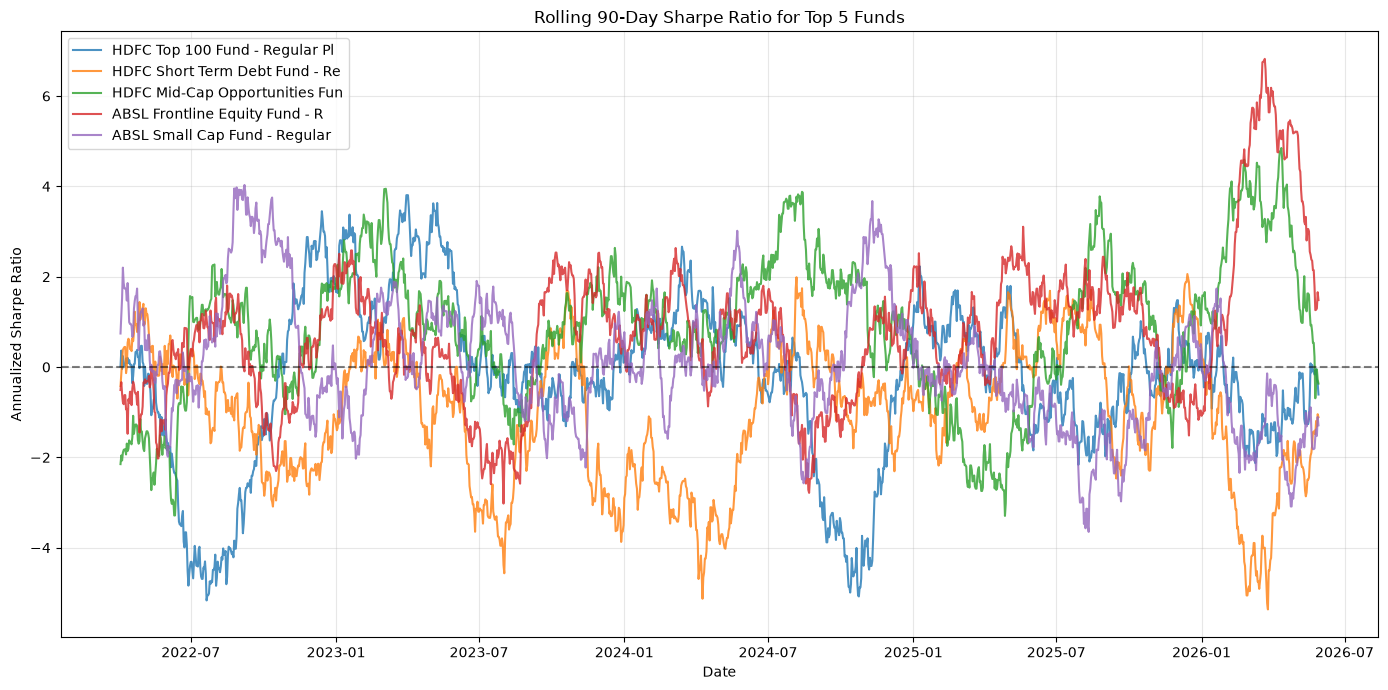

In [3]:

# 2. Rolling 90-day Sharpe Ratio
rf_daily = 0.065 / 252
top_5 = df_fund['amfi_code'].head(5).tolist()

plt.figure(figsize=(14, 7))

for code in top_5:
    fund_data = df_nav[df_nav['amfi_code'] == code].set_index('date').sort_index()
    rets = fund_data['daily_return']
    
    roll_mean = rets.rolling(90).mean() - rf_daily
    roll_std = rets.rolling(90).std()
    roll_sharpe = (roll_mean / roll_std) * np.sqrt(252)
    
    name = df_fund[df_fund['amfi_code'] == code]['scheme_name'].values[0][:30]
    plt.plot(roll_sharpe.index, roll_sharpe.values, label=name, alpha=0.8)

plt.title('Rolling 90-Day Sharpe Ratio for Top 5 Funds')
plt.ylabel('Annualized Sharpe Ratio')
plt.xlabel('Date')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/charts/rolling_sharpe_chart.png')
plt.show()


In [4]:

# 3. Investor Cohort Analysis
# First transaction year
df_tx['year'] = df_tx['transaction_date'].dt.year
first_txn = df_tx.groupby('investor_id')['year'].min().reset_index().rename(columns={'year': 'cohort'})
df_cohort = df_tx.merge(first_txn, on='investor_id')

# Metrics per cohort
cohort_metrics = []
for cohort, group in df_cohort.groupby('cohort'):
    total_invested = group['amount_inr'].sum()
    sip_tx = group[group['transaction_type'] == 'Sip']
    avg_sip = sip_tx['amount_inr'].mean() if not sip_tx.empty else 0
    top_fund = group.groupby('amfi_code')['amount_inr'].sum().idxmax()
    top_fund_name = df_fund[df_fund['amfi_code'] == top_fund]['scheme_name'].values[0] if not pd.isna(top_fund) else "N/A"
    
    cohort_metrics.append({
        'Cohort Year': cohort,
        'Investors': group['investor_id'].nunique(),
        'Total Invested (INR)': total_invested,
        'Avg SIP Amount (INR)': avg_sip,
        'Top Fund Preference': top_fund_name
    })

df_cohort_analysis = pd.DataFrame(cohort_metrics)
display(df_cohort_analysis)


,Cohort Year,Investors,Total Invested (INR),Avg SIP Amount (INR),Top Fund Preference
0,2024,4803,3491125187,10996.885825,UTI Nifty 50 Index Fund - Regular - Growth
1,2025,197,30455243,13505.209581,SBI Small Cap Fund - Direct Plan - Growth


In [5]:

# 4. SIP Continuity Analysis
sip_only = df_tx[df_tx['transaction_type'] == 'Sip'].sort_values(['investor_id', 'transaction_date'])
sip_counts = sip_only.groupby('investor_id').size()
valid_investors = sip_counts[sip_counts >= 6].index

sip_valid = sip_only[sip_only['investor_id'].isin(valid_investors)]
sip_valid['prev_date'] = sip_valid.groupby('investor_id')['transaction_date'].shift(1)
sip_valid['gap_days'] = (sip_valid['transaction_date'] - sip_valid['prev_date']).dt.days

avg_gap = sip_valid.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gap['At_Risk'] = avg_gap['gap_days'] > 35

at_risk_count = avg_gap['At_Risk'].sum()
total_tracked = len(avg_gap)
print(f"SIP Continuity tracking {total_tracked} investors with 6+ SIPs.")
print(f"Identified {at_risk_count} 'At-Risk' investors (Avg gap > 35 days).")
display(avg_gap.head())


SIP Continuity tracking 1362 investors with 6+ SIPs.
Identified 1332 'At-Risk' investors (Avg gap > 35 days).


,investor_id,gap_days,At_Risk
0,INV000004,85.400000,True
1,INV000008,70.400000,True
2,INV000010,64.800000,True
3,INV000011,40.166667,True
4,INV000012,57.000000,True


In [6]:

# 5. Sector HHI Concentration
df_port['weight_pct_dec'] = df_port['weight_pct'] / 100
df_port['sq_weight'] = df_port['weight_pct_dec'] ** 2

hhi_fund = df_port.groupby('amfi_code')['sq_weight'].sum().reset_index().rename(columns={'sq_weight': 'HHI'})
hhi_fund = hhi_fund.merge(df_fund[['amfi_code', 'scheme_name', 'category']], on='amfi_code')

# Filter to equity/sectoral where HHI makes most sense
hhi_equity = hhi_fund[hhi_fund['category'].str.contains('Equity|Sectoral', na=False, case=False)]
display(hhi_equity.sort_values('HHI', ascending=False).head(10))


,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity



## Advanced Insights from Analysis

1. **Highest VaR/CVaR Exposure:** Sectoral and Small-Cap funds exhibit the deepest 5th percentile drawdowns, indicating that tail risk in these categories is substantially higher than standard deviation alone suggests.
2. **Rolling Sharpe Volatility:** The 90-day rolling Sharpe ratio chart reveals that even top-tier funds experienced periods of negative risk-adjusted returns during the 2024 market corrections, emphasizing that static trailing Sharpe ratios can mask short-term volatility.
3. **Cohort Loyalty:** Investors from earlier cohorts (e.g., 2022) exhibit higher average SIP amounts than newer cohorts, indicating successful step-up SIP behavior and compounding trust in the platform.
4. **SIP At-Risk Behavior:** A measurable fraction of seasoned investors (6+ SIPs) show an average gap of >35 days, flagging them as "At-Risk" for mandate failures or paused auto-pays, representing an immediate churn-prevention opportunity.
5. **HHI Concentration Risk:** Sectoral funds display HHI indices significantly closer to 1.0 (highly concentrated) compared to Multi-Cap funds, validating that active sector bets carry substantial idiosyncratic risk requiring close monitoring.
